In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

In [4]:
filename='Y1.txt'
data = pd.read_csv(filename).to_numpy()

In [5]:
B = np.cumsum(data)
s_values = [8, 16, 32, 64, 128, 256]

In [6]:
# x = numero battito
# y = durata tra un battito e l'altro
def poly_fit(x, y, order=3):
    # revert order of coeffs from x^0 to x^3
    coeff = np.polyfit(x, y, order)
    p = np.poly1d(coeff)
    return p(x)

def get_deviation(y, s):
    #preparo array deviations
    deviations = np.zeros(len(y))

    x = np.arange(len(y))
    segment_length = 2*s
    # numero di segmenti su cui fare sliding
    
    for k in range(0, len(y), segment_length):
        # prendo un segmento e faccio fit
        x_slice = x[k:k+segment_length]
        y_slice = y[k:k+segment_length]
        y_fitted = poly_fit(x_slice, y_slice, order=3)
        #plt.plot(x_slice, y_slice)
        #plt.plot(x_slice, y_fitted)
        dev = y_slice-y_fitted
        
        deviations[k:k+segment_length] = dev
    return deviations

We now process the data and get all deviations for the the values in `s_values`

In [7]:
[[1,2], []]

[[1, 2], []]

In [13]:
# prepare the array
deltaB = [] # empty list, to be filled with s values
df = pd.DataFrame()
for s in s_values:
    z = get_deviation(B, s)
    deltaB.append(z)

    df[s] = z

C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19532\3882796652.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19532\3882796652.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19532\3882796652.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19532\3882796652.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19532\3882796652.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)
C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19532\3882796652.py:5: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)


In [15]:
df.index

RangeIndex(start=0, stop=8707, step=1)

In [8]:
trans = dev[s:]
trans1 = dev[:len(dev)-s]
deltaB = trans-trans1

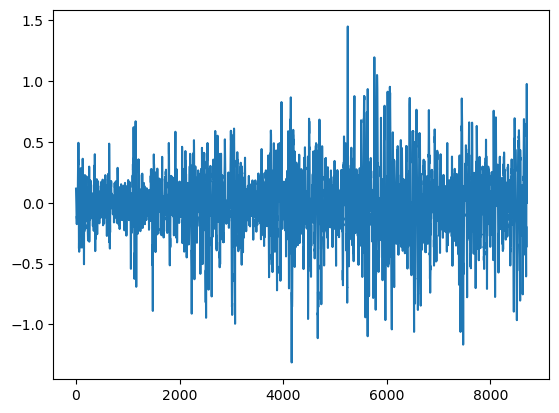

In [12]:
plt.plot(deltaB[3])

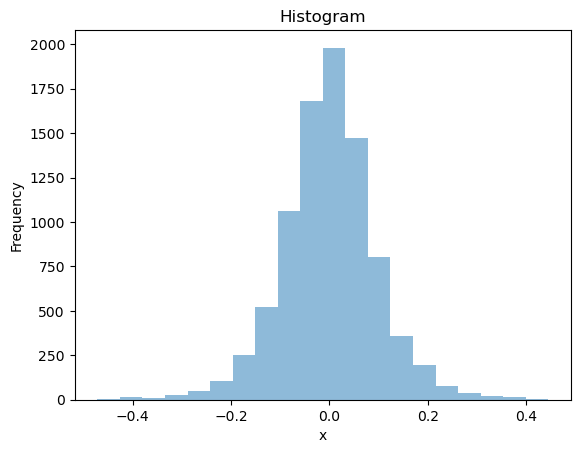

In [10]:
x=deltaB
sigma = np.std(x)
x_norm = x/sigma
# Create histogram data
pdf, bin_edges = np.histogram(x_norm, bins=int(np.sqrt(len(x))), density=True)

# Compute bin centers
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Plot histogram
plt.figure()
plt.hist(x, bins=20, alpha=0.5)
plt.xlabel("x")
plt.ylabel("Frequency")
plt.title("Histogram")
plt.show()

In [100]:
pdf

array([0.01797593, 0.        , 0.        , 0.        , 0.03595187,
       0.01797593, 0.        , 0.01797593, 0.        , 0.0539278 ,
       0.07190373, 0.        , 0.08987966, 0.0539278 , 0.        ,
       0.16178339, 0.19773526, 0.14380746, 0.21571119, 0.23368712,
       0.37749458, 0.53927798, 0.48535018, 0.79094103, 0.7729651 ,
       1.24033934, 1.61783393, 2.03128038, 2.69638988, 2.75031768,
       3.59518651, 4.40410347, 4.76362212, 4.67374246, 5.95003367,
       5.15909264, 5.35682789, 4.85350178, 4.18839228, 3.32554752,
       2.2649675 , 2.33687123, 1.68973766, 1.31224307, 1.15045968,
       0.93474849, 0.70106137, 0.62915764, 0.43142238, 0.37749458,
       0.23368712, 0.12583153, 0.17975933, 0.14380746, 0.1078556 ,
       0.07190373, 0.0539278 , 0.07190373, 0.03595187, 0.0539278 ,
       0.01797593, 0.01797593, 0.01797593, 0.0539278 ])

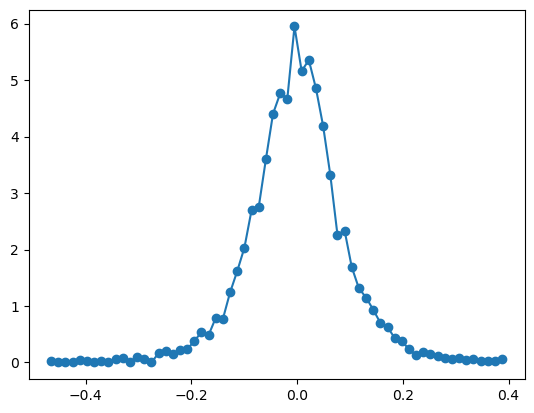

In [99]:
# Plot bin centers vs bin values
plt.plot(bin_centers, pdf, marker='o')